In [43]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

In [44]:
# LOAD DATASET

df = sns.load_dataset('tips')

print("Jumlah Data:", df.shape)

display(df.head())

Jumlah Data: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [47]:
# STATISTIK DESKRIPTIF

display(df.describe().round(2))

,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


In [46]:
# RATA-RATA TOTAL BILL DAN TIP PER HARI

daily_summary = df.groupby('day', observed=False).agg(
    Rata_rata_Total_Bill=('total_bill', 'mean'),
    Rata_rata_Tip=('tip', 'mean'),
    Jumlah_Transaksi=('total_bill', 'count')
).round(2)

display(daily_summary)

,Rata_rata_Total_Bill,Rata_rata_Tip,Jumlah_Transaksi
day,,,
Thur,17.68,2.77,62
Fri,17.15,2.73,19
Sat,20.44,2.99,87
Sun,21.41,3.26,76


In [48]:
# RINGKASAN DATASET

summary_data = {
    "Metrik": [
        "Jumlah Transaksi",
        "Rata-rata Total Bill",
        "Median Total Bill",
        "Total Bill Minimum",
        "Total Bill Maksimum",
        "Rata-rata Tip",
        "Korelasi Total Bill dan Tip"
    ],
    "Nilai": [
        len(df),
        round(df['total_bill'].mean(), 2),
        round(df['total_bill'].median(), 2),
        round(df['total_bill'].min(), 2),
        round(df['total_bill'].max(), 2),
        round(df['tip'].mean(), 2),
        round(df['total_bill'].corr(df['tip']), 2)
    ]
}

summary_df = pd.DataFrame(summary_data)

display(summary_df)

,Metrik,Nilai
0,Jumlah Transaksi,244.00
1,Rata-rata Total Bill,19.79
2,Median Total Bill,17.80
3,Total Bill Minimum,3.07
4,Total Bill Maksimum,50.81
5,Rata-rata Tip,3.00
6,Korelasi Total Bill dan Tip,0.68


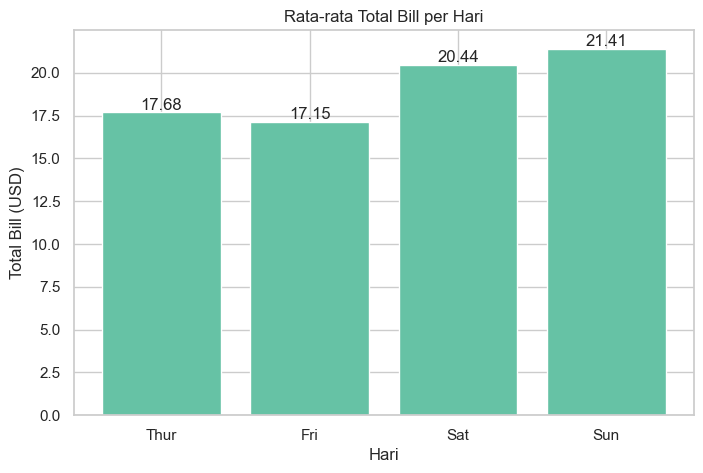

In [45]:
# BAR CHART TOTAL BILL PER HARI

avg_bill_by_day = (
    df.groupby('day', observed=False)['total_bill']
    .mean()
    .round(2)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    avg_bill_by_day.index.astype(str),
    avg_bill_by_day.values
)

plt.title('Rata-rata Total Bill per Hari')
plt.xlabel('Hari')
plt.ylabel('Total Bill (USD)')

plt.bar_label(bars)

plt.show()

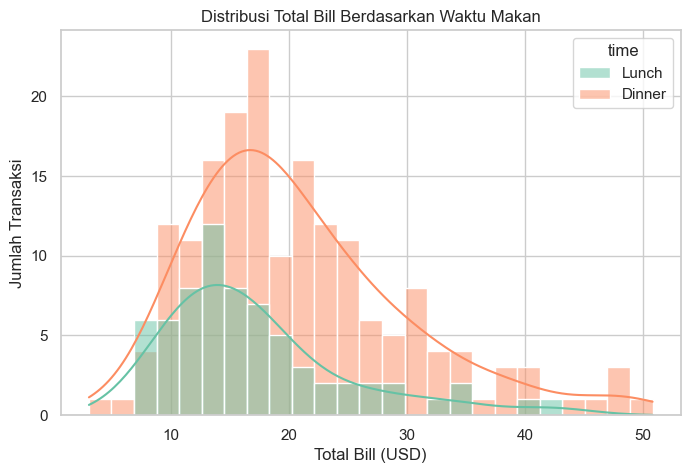

In [49]:
# HISTOGRAM TOTAL BILL

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    bins=25
)

plt.title('Distribusi Total Bill Berdasarkan Waktu Makan')
plt.xlabel('Total Bill (USD)')
plt.ylabel('Jumlah Transaksi')

plt.show()

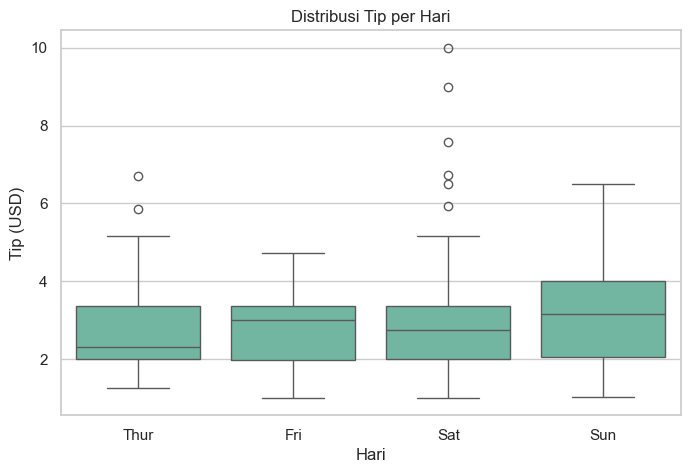

In [50]:
# BOXPLOT TIP PER HARI

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='day',
    y='tip',
    order=['Thur', 'Fri', 'Sat', 'Sun']
)

plt.title('Distribusi Tip per Hari')
plt.xlabel('Hari')
plt.ylabel('Tip (USD)')

plt.show()

In [51]:
# RINGKASAN TIP PER HARI

tip_summary = df.groupby('day', observed=False).agg(
    jumlah_transaksi=('tip', 'count'),
    rata_rata_tip=('tip', 'mean'),
    median_tip=('tip', 'median'),
    tip_minimum=('tip', 'min'),
    tip_maksimum=('tip', 'max')
).round(2)

display(tip_summary)

,jumlah_transaksi,rata_rata_tip,median_tip,tip_minimum,tip_maksimum
day,,,,,
Thur,62,2.77,2.30,1.25,6.70
Fri,19,2.73,3.00,1.00,4.73
Sat,87,2.99,2.75,1.00,10.00
Sun,76,3.26,3.15,1.01,6.50
